# 모듈 임포트

In [1]:
!pip install torchinfo

In [2]:
import os
import random

import numpy as np
import torch
from torch import nn

from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

from torchinfo import summary

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.5.1+cu124'

In [3]:
def reset_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)    # 파이썬 환경변수 시드 고정
    np.random.seed(seed)
    torch.manual_seed(seed) # cpu 연산 무작위 고정
    torch.cuda.manual_seed(seed) # gpu 연산 무작위 고정
    torch.backends.cudnn.deterministic = True  # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


# 글로벌 변수 선언

In [7]:
import argparse
import torch

parser = argparse.ArgumentParser()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
parser.add_argument('--device', default=device)
parser.add_argument('--NUM_EPOCHS', default=30)
parser.add_argument('--NUM_TRIALS', default=5)
parser.add_argument('--BATCH_SIZE', default=32)
parser.add_argument('--best_efficientnet_model', default='best_efficientnet_model.pt')
parser.add_argument('--best_mobilenet_model', default='best_mobilenet_model.pt')
parser.add_argument('--best_vgg_model', default='best_vgg_model.pt')

# args = parser.parse_args() # python file 용
args, _ = parser.parse_known_args() # jupyter 용
print(f'args : ', args)

args :  Namespace(device=device(type='cuda', index=0), NUM_EPOCHS=30, NUM_TRIALS=5, BATCH_SIZE=32, best_efficientnet_model='best_efficientnet_model.pt', best_mobilenet_model='best_mobilenet_model.pt', best_vgg_model='best_vgg_model.pt')


# 데이터 로드

In [8]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi" # data/pizza_steak_sushi

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)


Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [9]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


In [10]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.


In [11]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## EDA

### PIL

Random image path: data/pizza_steak_sushi/test/sushi/3837522.jpg
Image class: sushi
Image height: 512
Image width: 512


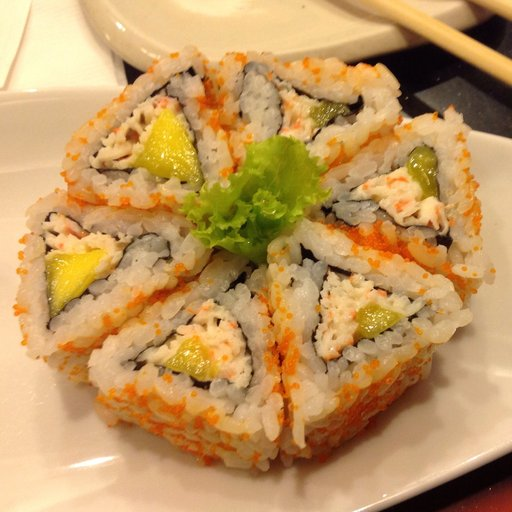

In [12]:
import random
from PIL import Image

# Set seed
reset_seeds()

# 1. 모든 폴더에 있는 모든 jpg 조회
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. 랜덤하게 이미지 가져옴
random_image_path = random.choice(image_path_list)
# choices -> 복원 추출
# choice -> 비복원 추출

# 3. 랜덤 추출된 jpg 파일의 부모 폴더를 class로 지정 (pizza/steak/sushi)
image_class = random_image_path.parent.stem

# 4. 랜덤 이미지 추
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")

img


### matplotlib

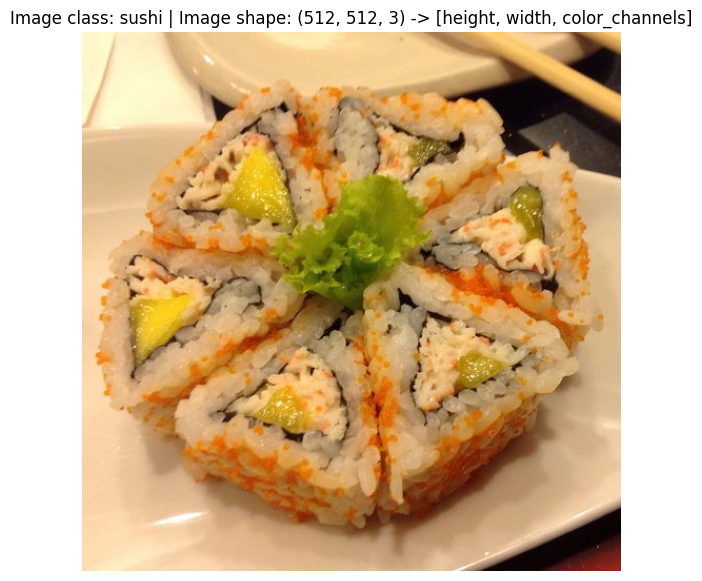

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);


## 데이터 증강(옵션)

In [14]:
# 학습용 전체 데이터들....
train_dir_list = list(train_dir.glob("*/*.jpg"))
print(f'데이터 증강전: {len(train_dir_list)}')


데이터 증강전: 225


In [15]:
for im_path in train_dir_list:
  _im = Image.open(im_path) # 원본 이미지 로드...
  _im_name = str(im_path).split(".")[0] # 원본 이미지 이름..

  # 상하반전... 저장
  _im.rotate(180).save(_im_name+"_rotate.jpg")
  # 좌우반전... 저장
  _im.transpose(Image.FLIP_LEFT_RIGHT).save(_im_name+"_transpose.jpg")


In [16]:
# 학습용 전체 데이터들....
train_dir_list = list(train_dir.glob("*/*.jpg"))
print(f'데이터 증강후: {len(train_dir_list)}')


데이터 증강후: 675


# Experiment

- [오류 해결 방법](https://github.com/pytorch/vision/issues/7744)
> `RuntimeError: invalid hash value (expected "3dd342df", got "7f5810bc96def8f7552d5b7e68d53c4786f81167d28291b21c0d90e1fca14934")`

In [17]:
from torchvision.models._api import WeightsEnum
from torch.hub import load_state_dict_from_url

def get_state_dict(self, *args, **kwargs):
    kwargs.pop("check_hash")
    return load_state_dict_from_url(self.url, *args, **kwargs)

WeightsEnum.get_state_dict = get_state_dict


## Engine

### train step

In [18]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(args.device), y.to(args.device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


### test step

In [19]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(args.device), y.to(args.device) # X (), y ()

            # 1. Forward pass
            test_pred_logits = model(X) # pred ()

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1) # pred_labes ()
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


### early stopping

In [20]:
class EarlyStopper(object):

    def __init__(self, num_trials, save_path):
        self.num_trials = num_trials
        self.trial_counter = 0
        self.best_loss = np.inf
        self.save_path = save_path

    def is_continuable(self, model, loss):
        if loss < self.best_loss: # 현재 loss가 최고 loss보다 더 낮은 경우
            self.best_loss = loss # 최고 loss를 현재 loss로 업데이트
            self.trial_counter = 0 # 초기화
            torch.save(model, self.save_path) # 최고 loss를 갖은 모델 저장
            return True
        elif self.trial_counter + 1 < self.num_trials: # 현재 loss가 최고 loss보다 작은 경우 & max 시도횟수보다 현재 시도횟수가 작은 경우
            self.trial_counter += 1 # 기존 시도횟수 + 1
            return True
        else: # 현재 정확도가 최고 정확도보다 작은 경우 & 현재 시도횟수가 max 시도횟수보다 큰 경우
            return False

    def get_best_model(self, device=args.device):
        return torch.load(self.save_path).to(device)


### Main

In [21]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def main(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          early_stopper,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        # 6. early stopper
        if not early_stopper.is_continuable(model, test_loss):
            print(f'validation: best loss: {early_stopper.best_loss}')
            break

    # 7. Return the filled results at the end of the epochs
    return results


### Dataset Class

In [22]:
from typing import Tuple, Dict, List

# Make function to find classes in target directory
def find_classes(directory):
    # 1. Get the class names by scanning the target directory
    # classes -> ['pizza', 'steak', 'sushi']
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())


    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # 3. Crearte a dictionary of index labels (computers prefer numerical rather than string labels)
    # class_to_idx -> classes to 숫자(인덱스)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [23]:
classes, class_to_idx = find_classes(train_dir)
classes, class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [24]:
import pathlib

# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) # note: you'd have to update this if you've got .png's or .jpeg's
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)


### plot loss curves

In [25]:
def plot_loss_curves(results):

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();


## Exeriment - EfficientNet

### Dataset
- Data Augmentation of Pretrained Model

In [26]:
efficientnet_weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
efficientnet_weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [27]:
# Get the transforms used to create our pretrained weights
efficientnet_transforms = efficientnet_weights.transforms()
efficientnet_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [28]:
reset_seeds()

efficientnet_train_dataset = ImageFolderCustom(targ_dir=train_dir,
                                      transform=efficientnet_transforms)
efficientnet_test_dataset = ImageFolderCustom(targ_dir=test_dir,
                                     transform=efficientnet_transforms)

len(efficientnet_train_dataset), len(efficientnet_test_dataset)

(675, 75)

### DataLoader

In [29]:
reset_seeds()

efficientnet_train_dataloader = DataLoader(efficientnet_train_dataset,
                                        batch_size=args.BATCH_SIZE,
                                        shuffle=True)
efficientnet_test_dataloader = DataLoader(efficientnet_test_dataset,
                                    batch_size=args.BATCH_SIZE,
                                    shuffle=True)

len(efficientnet_train_dataloader), len(efficientnet_test_dataloader)

(22, 3)

### Pretrained Model

In [30]:
reset_seeds()

# 사전학습(pre-training) 모델 인스턴스 생성
efficientnet_model = torchvision.models.efficientnet_b0(weights=efficientnet_weights).to(args.device)
efficientnet_model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 385MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [31]:
summary(model=efficientnet_model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

### Fine Tuning

In [32]:
for param in efficientnet_model.features.parameters():
    param.requires_grad = False

In [33]:
reset_seeds()

output_shape = len(efficientnet_train_dataset.classes)

# Recreate the classifier layer and seed it to the target device
efficientnet_model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(args.device)


In [34]:
summary(model=efficientnet_model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

### Training

In [35]:
# Set random seeds
reset_seeds()

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=efficientnet_model.parameters(), lr=0.001)

early_stopper = EarlyStopper(num_trials=args.NUM_TRIALS, save_path=args.best_efficientnet_model)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train
efficientnet_result = main(model=efficientnet_model,
                        train_dataloader=efficientnet_train_dataloader,
                        test_dataloader=efficientnet_test_dataloader,
                        optimizer=optimizer,
                        early_stopper=early_stopper,
                        loss_fn=loss_fn,
                        epochs=args.NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9035 | train_acc: 0.6449 | test_loss: 0.6246 | test_acc: 0.8456
Epoch: 2 | train_loss: 0.5598 | train_acc: 0.8769 | test_loss: 0.4781 | test_acc: 0.8968
Epoch: 3 | train_loss: 0.4385 | train_acc: 0.8968 | test_loss: 0.4521 | test_acc: 0.8570
Epoch: 4 | train_loss: 0.3682 | train_acc: 0.9086 | test_loss: 0.3655 | test_acc: 0.8968
Epoch: 5 | train_loss: 0.3189 | train_acc: 0.9233 | test_loss: 0.3357 | test_acc: 0.8665
Epoch: 6 | train_loss: 0.2957 | train_acc: 0.9200 | test_loss: 0.3469 | test_acc: 0.8769
Epoch: 7 | train_loss: 0.2423 | train_acc: 0.9517 | test_loss: 0.3075 | test_acc: 0.8968
Epoch: 8 | train_loss: 0.2265 | train_acc: 0.9493 | test_loss: 0.2944 | test_acc: 0.8958
Epoch: 9 | train_loss: 0.2016 | train_acc: 0.9688 | test_loss: 0.2971 | test_acc: 0.9072
Epoch: 10 | train_loss: 0.1953 | train_acc: 0.9659 | test_loss: 0.3421 | test_acc: 0.8873
Epoch: 11 | train_loss: 0.2215 | train_acc: 0.9380 | test_loss: 0.2774 | test_acc: 0.9062
Epoch: 12 | train_l

### loss 그래프

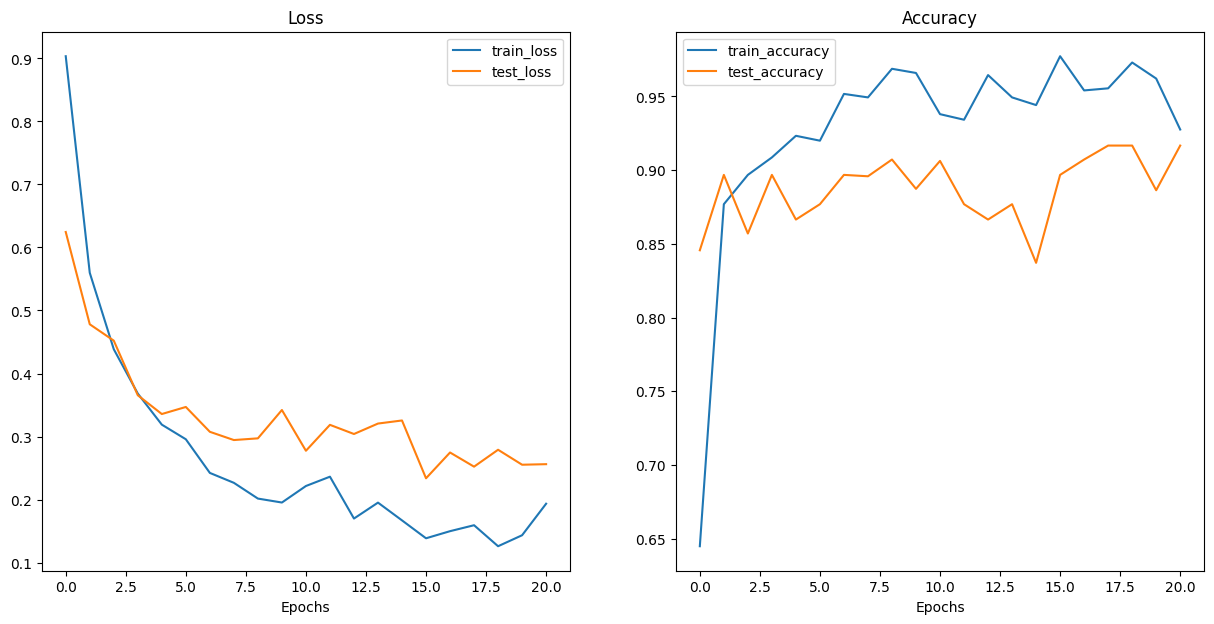

In [36]:
plot_loss_curves(efficientnet_result)

### Best Model Score

In [37]:
best_efficientnet_model =  early_stopper.get_best_model(device=args.device)


<ipython-input-20-3faae2b4f7a6>:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.save_path).to(device)


In [38]:
reset_seeds()

test_acc = 0

best_efficientnet_model.eval()

with torch.inference_mode():
  for batch, (X, y) in enumerate(efficientnet_test_dataloader):
    # Send data and targets to target device
    X, y = X.to(args.device), y.to(args.device)
    # Do the forward pass
    test_pred_logits = best_efficientnet_model(X)

    y_pred_class = torch.argmax(torch.softmax(test_pred_logits, dim=1), dim=1)
    test_acc += (y_pred_class == y).sum().item()/len(test_pred_logits)

efficientnet_test_acc = test_acc / len(efficientnet_test_dataloader)
print(f'best_efficientnet_model에 대한 정확도: {efficientnet_test_acc}')

best_efficientnet_model에 대한 정확도: 0.8768939393939394


## Predictions

In [39]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        transform: torchvision.transforms,
                        image_size: Tuple[int, int] = (224, 224),
                        device: torch.device="cpu"):

    # 2. Open image
    img = Image.open(image_path)

    # 3. Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])

    ### Predict on image ###

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. Make a prediction on image with an extra dimension and send it to the target device
      target_image_pred = model(transformed_image.to(device))

    # 8. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

In [40]:
class_names = efficientnet_train_dataset.classes
class_names

['pizza', 'steak', 'sushi']

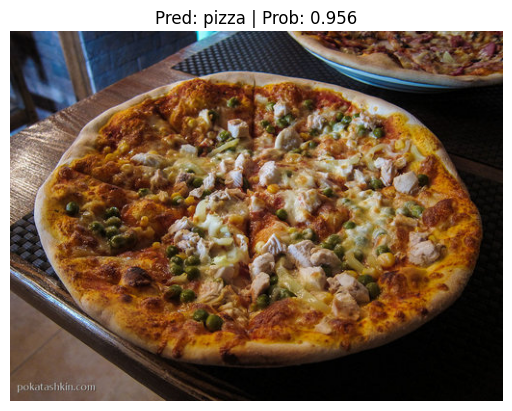

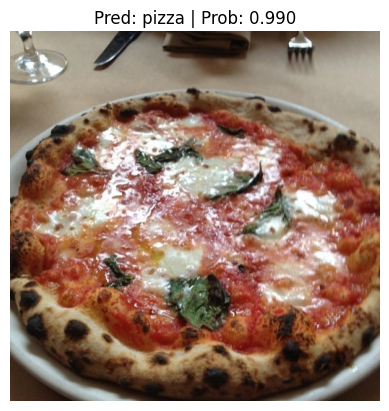

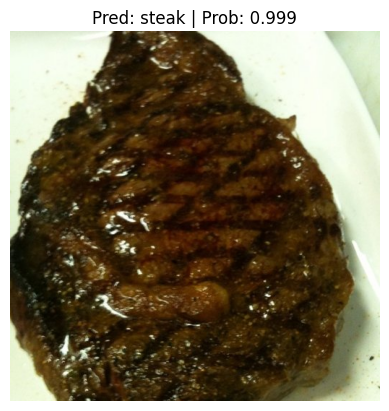

In [41]:
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=best_efficientnet_model,
                        image_path=image_path,
                        class_names=class_names,
                        transform=efficientnet_weights.transforms(), # optionally pass in a specified transform from our pretrained model weights
                        image_size=(224, 224),
                        device=args.device)

# Predictions of XAI

## [Saliency Map](https://kyujinpy.tistory.com/58)
- AI Model을 만들 때, 우리는 왜 결과물이 좋은지 이해하지 못한다.
  - 무슨 패턴을 보고, 어디를 보고 이러한 output을 도출하는지 모르기 때문에 AI의 성능이 잘 나오거나 잘 나오지 않을 때 원인을 찾지 못한다.
- 이러한 현상을 `Black Box`라고 하며, `Black Box`를 설명할 수 있는 방법에 대해서 연구하는 기술을 `XAI(eXplainable AI)`라고 한다.
  - `Saliency Map`은 `XAI`의 basic한 논문이다.

- `Saliency Map`은 각 좌표의 미분 값을 의미한다.
  - 즉 위의 사진에서 색깔이 밝을 수록, AI가 이 사진을 강아지라고 판단하는데 큰 도움을 줬다는 의미가 된다.
  - `Saliency Map`을 보면 강아지의 형태가 보이고, '눈코입'을 주로 보고 강아지라고 판단한다고 얘기할 수 있다.

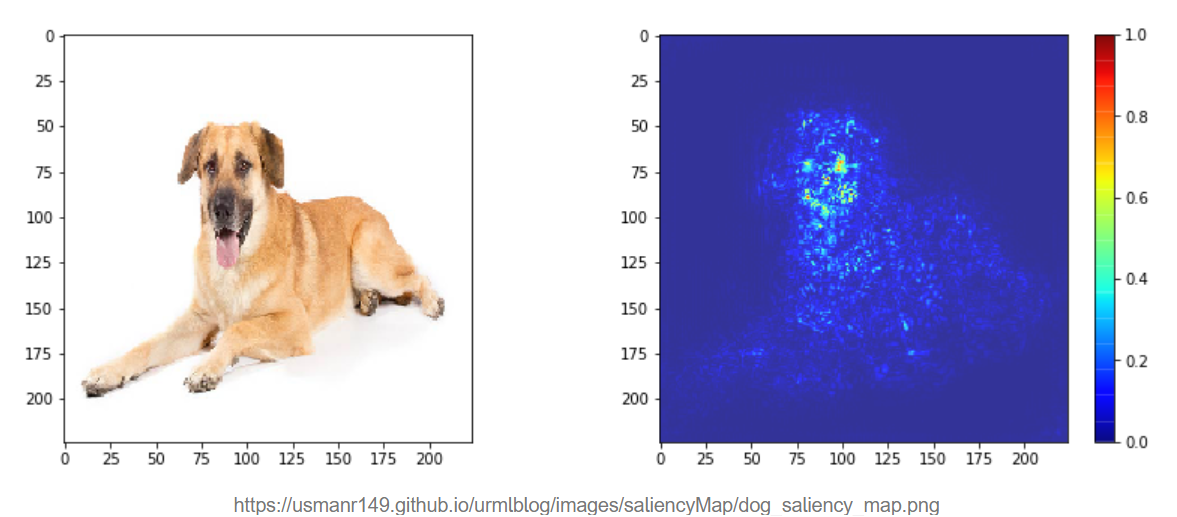

## [SHAP](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Explain%20MobilenetV2%20using%20the%20Partition%20explainer%20%28PyTorch%29.html)
- SHAP(Shapley Additive exPlanations)는 Shapley value와 피쳐간 독립성을 기초로 인공지능, 특히 기계 학습 모델의 예측을 설명하는 데 적용한 설명 모델Explainer Model이다.
- 이는 모델의 각 입력 변수가 최종 예측 결과에 미친 기여도를 수치화하여, 모델이 어떻게 그리고 왜 특정 결정을 내렸는지를 이해할 수 있게 돕는다.

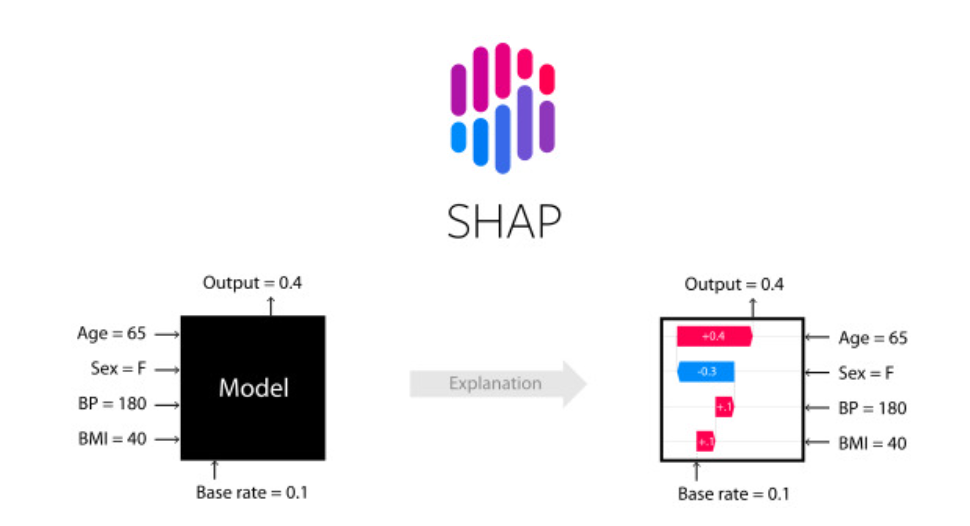

### Sample

In [42]:
import json

import numpy as np
import torch
import torchvision

import shap

In [44]:
# 사전학습 모델
model = torchvision.models.mobilenet_v2(pretrained=True, progress=False)
model.to(device)
# 예측 모듈 -> 학습 x
model.eval()

# imagenet -> 유명한 이미지 데이터셋
X, y = shap.datasets.imagenet50()

In [45]:
# Getting ImageNet 1000 class names
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with open(shap.datasets.cache(url)) as file:
    class_names = [v[1] for v in json.load(file).values()]
print("Number of ImageNet classes:", len(class_names))

Number of ImageNet classes: 1000


In [46]:
# Prepare data transformation pipeline

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


def nhwc_to_nchw(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 4:
        x = x if x.shape[1] == 3 else x.permute(0, 3, 1, 2)
    elif x.dim() == 3:
        x = x if x.shape[0] == 3 else x.permute(2, 0, 1)
    return x


def nchw_to_nhwc(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 4:
        x = x if x.shape[3] == 3 else x.permute(0, 2, 3, 1)
    elif x.dim() == 3:
        x = x if x.shape[2] == 3 else x.permute(1, 2, 0)
    return x


transform = [
    torchvision.transforms.Lambda(nhwc_to_nchw),
    torchvision.transforms.Lambda(lambda x: x * (1 / 255)),
    torchvision.transforms.Normalize(mean=mean, std=std),
    torchvision.transforms.Lambda(nchw_to_nhwc),
]

inv_transform = [
    torchvision.transforms.Lambda(nhwc_to_nchw),
    torchvision.transforms.Normalize(
        mean=(-1 * np.array(mean) / np.array(std)).tolist(),
        std=(1 / np.array(std)).tolist(),
    ),
    torchvision.transforms.Lambda(nchw_to_nhwc),
]

transform = torchvision.transforms.Compose(transform)
inv_transform = torchvision.transforms.Compose(inv_transform)

In [47]:
def predict(img: np.ndarray) -> torch.Tensor:
    img = nhwc_to_nchw(torch.Tensor(img))
    img = img.to(device)
    output = model(img)
    return output

In [48]:
# Check that transformations work correctly
Xtr = transform(torch.Tensor(X))
out = predict(Xtr[1:3])
classes = torch.argmax(out, axis=1).cpu().numpy()
print(f"Classes: {classes}: {np.array(class_names)[classes]}")

Classes: [132 814]: ['American_egret' 'speedboat']


In [49]:
topk = 4
batch_size = 50
n_evals = 10000

# define a masker that is used to mask out partitions of the input image.
masker_blur = shap.maskers.Image("blur(128,128)", Xtr[0].shape)

# create an explainer with model and image masker
explainer = shap.Explainer(predict, masker_blur, output_names=class_names)

# feed only one image
# here we explain two images using 100 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(
    Xtr[1:2],
    max_evals=n_evals,
    batch_size=batch_size,
    outputs=shap.Explanation.argsort.flip[:topk],
)

  0%|          | 0/9998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:26, 26.49s/it]               


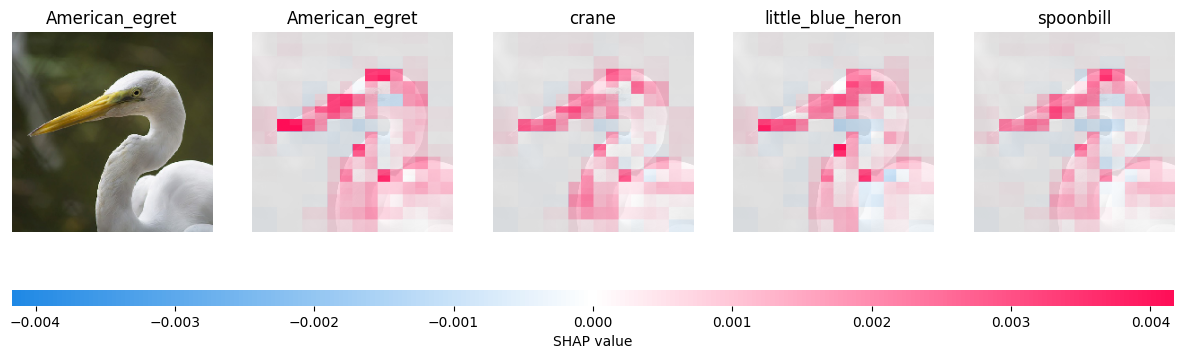

In [50]:
shap_values.data = inv_transform(shap_values.data).cpu().numpy()[0]
shap_values.values = [val for val in np.moveaxis(shap_values.values[0], -1, 0)]

shap.image_plot(
    shap_values=shap_values.values,
    pixel_values=shap_values.data,
    labels=shap_values.output_names,
    true_labels=[class_names[132]],
)

### PizzaSteakSushi

In [51]:
# Get the transforms used to create our pretrained weights
auto_transforms = efficientnet_weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [53]:
# Prepare data transformation pipeline
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


# (batch, row, column, color) -> (batch, color, row, column)
def nhwc_to_nchw(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 4:
        x = x if x.shape[1] == 3 else x.permute(0, 3, 1, 2)
    elif x.dim() == 3:
        x = x if x.shape[0] == 3 else x.permute(2, 0, 1)
    return x

# (batch, color, row, column) -> (batch, row, column, color)
def nchw_to_nhwc(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 4:
        x = x if x.shape[3] == 3 else x.permute(0, 2, 3, 1)
    elif x.dim() == 3:
        x = x if x.shape[2] == 3 else x.permute(1, 2, 0)
    return x


transform = [
    torchvision.transforms.Lambda(nhwc_to_nchw), #
    torchvision.transforms.Lambda(lambda x: x * (1 / 255)), # data scaling
    torchvision.transforms.Normalize(mean=mean, std=std), # 데이터 정규화
    torchvision.transforms.Lambda(nchw_to_nhwc),
]

inv_transform = [
    torchvision.transforms.Lambda(nhwc_to_nchw),
    torchvision.transforms.Normalize(
        mean=(-1 * np.array(mean) / np.array(std)).tolist(),
        std=(1 / np.array(std)).tolist(),
    ),
    torchvision.transforms.Lambda(nchw_to_nhwc),
]

transform = torchvision.transforms.Compose(transform)
inv_transform = torchvision.transforms.Compose(inv_transform)

In [55]:
def predict(img: np.ndarray) -> torch.Tensor:
    # 이미지 전처리
    img = nhwc_to_nchw(torch.Tensor(img))
    img = img.to(args.device)
    output = best_efficientnet_model(img) # (batch, color, row, column)
    return output # 모델의 예측값

In [56]:
img = Image.open(test_image_path_sample[0]) # 하나의 이미지 로드
# unsqueeze(dim=0) -> (batch(=1), row, column, color)
arr_lst = np.array(img)[np.newaxis, :]
arr_lst.shape

(1, 384, 512, 3)

In [57]:
np.concatenate((arr_lst,arr_lst,arr_lst), axis=0).shape

(3, 384, 512, 3)

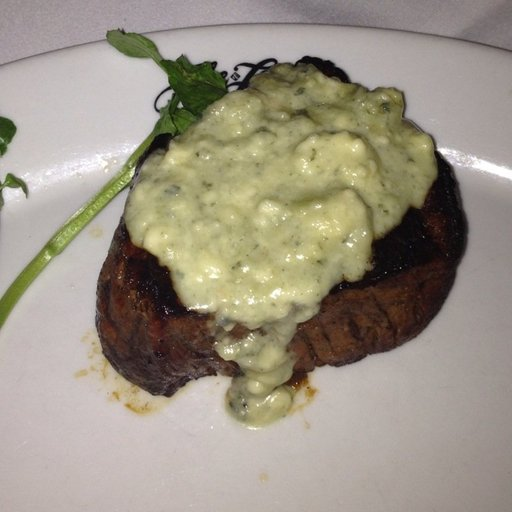

In [58]:
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

img = Image.open(test_image_path_sample[0])
img

In [59]:
class_names = efficientnet_train_dataset.classes
class_names

['pizza', 'steak', 'sushi']

In [60]:
# Check that transformations work correctly
# Xtr -> (batch(=1), color, row, column)
Xtr = transform(torch.Tensor(np.array(img))).unsqueeze(dim=0)
# out -> (batch(=1), targets(=3))
out = predict(Xtr)
# classes -> (batch(=target index),)
classes = torch.argmax(out, axis=1).cpu().numpy()
print(f"Classes: {classes}: {np.array(class_names)[classes]}")

Classes: [1]: ['steak']


In [61]:
Xtr.shape

torch.Size([1, 512, 512, 3])

In [62]:
import shap

topk = len(class_names)
batch_size = 50
n_evals = 10000

# define a masker that is used to mask out partitions of the input image.
masker_blur = shap.maskers.Image("blur(128,128)", Xtr[0].shape)

# create an explainer with model and image masker
# predict -> 사전학습 모델
# output_names -> target 명
explainer = shap.Explainer(predict, masker_blur, output_names=class_names)

# feed only one image
# here we explain two images using 100 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(
    Xtr, # 이미지 데이터
    max_evals=n_evals, # 사전학습 모델이 예측을 10000번 함
    batch_size=batch_size,
    outputs=shap.Explanation.argsort.flip[:topk],
)

  0%|          | 0/9998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:56, 116.75s/it]              


In [64]:
# shap_values.values -> (batch, row, column, color, topk(=3))
shap_values.data.shape, shap_values.values.shape

(torch.Size([1, 512, 512, 3]), (1, 512, 512, 3, 3))

In [65]:
shap_values.data = inv_transform(shap_values.data).cpu().numpy()[0]
shap_values.values = [val for val in np.moveaxis(shap_values.values[0], -1, 0)]

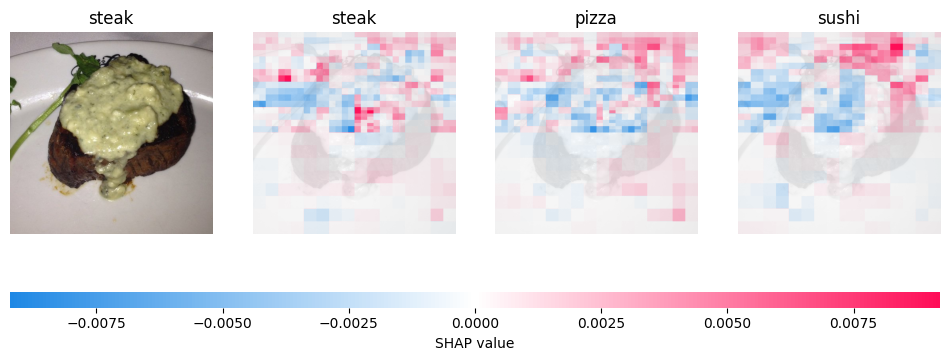

In [66]:
shap.image_plot(
    shap_values=shap_values.values,
    pixel_values=shap_values.data,
    labels=shap_values.output_names,
    true_labels=[class_names[classes[0]]]
)

## [Captum](https://tutorials.pytorch.kr/recipes/recipes/Captum_Recipe.html)
- Pytorch 기반, facebook이 개발한 오픈소스 라이브러리
- Captum을 사용하면 데이터 특징(features)이 모델의 예측 또는 뉴런 활성화에 미치는 영향을 이해하고, 모델의 동작 방식을 알 수 있습니다.

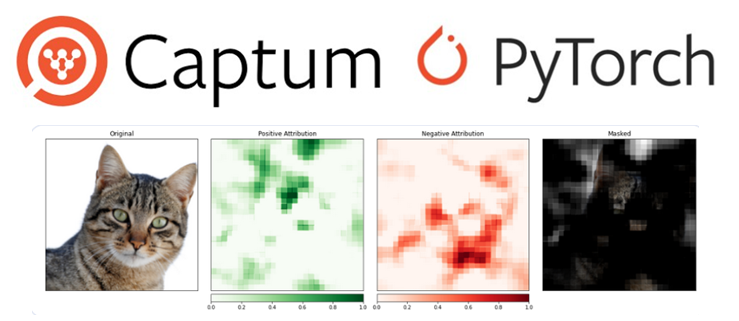

In [67]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

### Sample

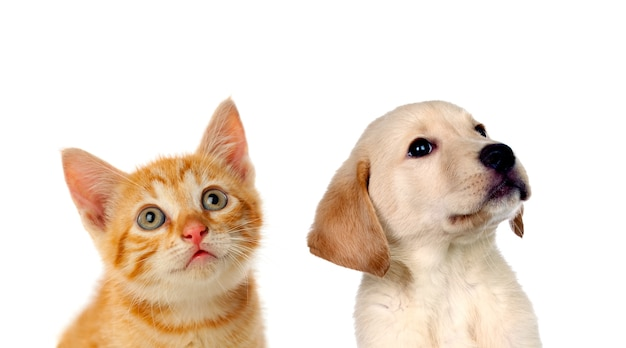

In [68]:
import requests
from PIL import Image
from io import BytesIO

response = requests.get("https://image.freepik.com/free-photo/two-beautiful-puppies-cat-dog_58409-6024.jpg")
img = Image.open(BytesIO(response.content))
img

In [70]:
import torchvision
from torchvision import models, transforms

center_crop = transforms.Compose([
 transforms.Resize(256),
 transforms.CenterCrop(224),
])

normalize = transforms.Compose([
    transforms.ToTensor(),               # 이미지를 0에서 1사이의 값을 가진 Tensor로 변환
    transforms.Normalize(                # 0을 중심으로 하는 imagenet 픽셀의 RGB 분포를 따르는 정규화
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
    )
])
input_img = normalize(center_crop(img)).unsqueeze(0)
input_img.shape

torch.Size([1, 3, 224, 224])

In [71]:
model = torchvision.models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 310MB/s]


- [ImageNet-1k](https://www.kaggle.com/datasets/sautkin/imagenet1k1)
  - [라벨정보](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a)

In [73]:
from captum.attr import Occlusion

occlusion = Occlusion(model)

strides = (3, 9, 9)               # 작을수록 = 세부적인 속성이지만 느림
target=208,                       # ImageNet에서 "Labrador retriever"의 인덱스
sliding_window_shapes=(3,45, 45)  # 객체의 모양을 변화시키기에 충분한 크기를 선택
baselines = 0                     # 이미지를 가릴 값, 0은 회색

attribution_dog = occlusion.attribute(input_img,
                                       strides = strides,
                                       target=target,
                                       sliding_window_shapes=sliding_window_shapes,
                                       baselines=baselines)


target=283,                       # ImageNet에서 "Persian cat"의 인덱스
attribution_cat = occlusion.attribute(input_img,
                                       strides = strides,
                                       target=target,
                                       sliding_window_shapes=sliding_window_shapes,
                                       baselines=0)

In [74]:
attribution_dog.shape

torch.Size([1, 3, 224, 224])

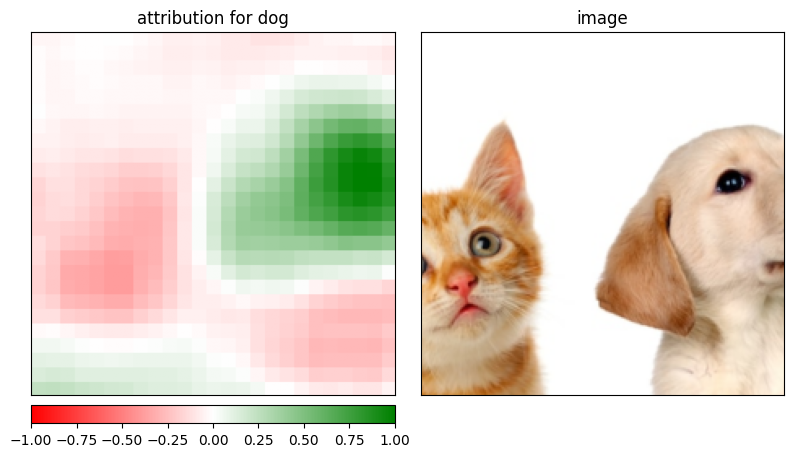

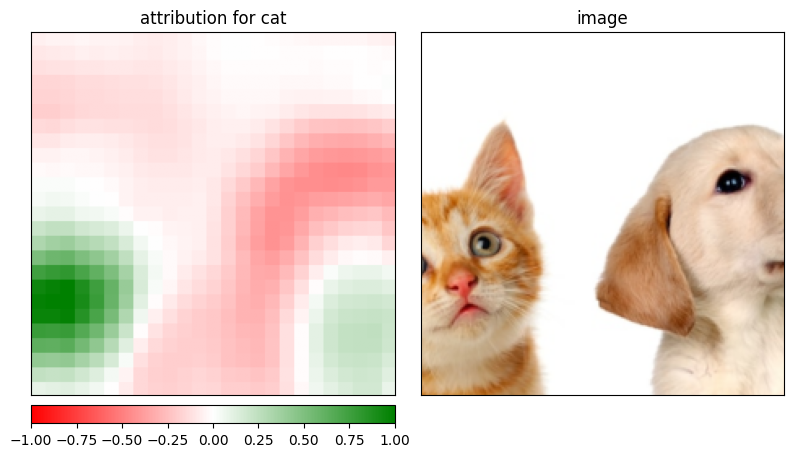

In [75]:
import numpy as np
from captum.attr import visualization as viz

# 계산 속성 Tensor를 이미지 같은 numpy 배열로 변환합니다.
# attribution_dog.squeeze() -> (color, row, column)
# attribution_dog.squeeze().cpu().detach().numpy() -> numpy 형변환
# np.transpose(numpy, (1,2,0)) -> (row, column, color)
attribution_dog = np.transpose(attribution_dog.squeeze().cpu().detach().numpy(), (1,2,0))

vis_types = ["heat_map", "original_image"]
vis_signs = ["all", "all"] # "positive", "negative", 또는 모두 표시하는 "all"
# positive 속성은 해당 영역의 존재가 예측 점수를 증가시킨다는 것을 의미합니다.
# negative 속성은 해당 영역의 존재가 예측 점수를 낮추는 오답 영역을 의미합니다.

_ = viz.visualize_image_attr_multiple(attribution_dog,
                                      np.array(center_crop(img)),
                                      vis_types,
                                      vis_signs,
                                      ["attribution for dog", "image"],
                                      show_colorbar = True
                                     )


attribution_cat = np.transpose(attribution_cat.squeeze().cpu().detach().numpy(), (1,2,0))

_ = viz.visualize_image_attr_multiple(attribution_cat,
                                      np.array(center_crop(img)),
                                      ["heat_map", "original_image"],
                                      ["all", "all"], # positive/negative 속성 또는 all
                                      ["attribution for cat", "image"],
                                      show_colorbar = True
                                     )

### PizzaSteakSushi

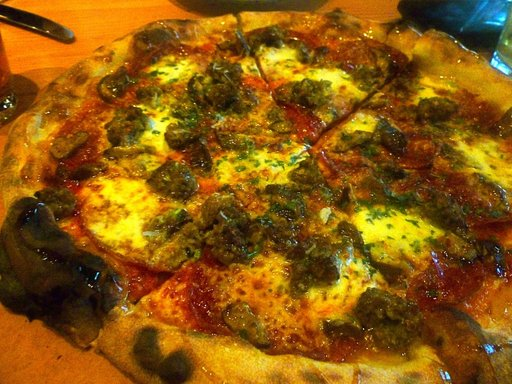

In [76]:
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot


img = Image.open(test_image_path_sample[0])
img

In [77]:
class_names

['pizza', 'steak', 'sushi']

In [78]:
# Get the transforms used to create our pretrained weights
auto_transforms = efficientnet_weights.transforms()
input_img = auto_transforms(img).unsqueeze(0).to(args.device)
input_img.shape

torch.Size([1, 3, 224, 224])

In [79]:
model = best_efficientnet_model.eval()

In [80]:
from captum.attr import Occlusion

occlusion = Occlusion(model)

strides = (3, 9, 9)               # 작을수록 = 세부적인 속성이지만 느림
target=0,                         # 해당 이미지의 인덱스 수정
sliding_window_shapes=(3,45,45)  # 객체의 모양을 변화시키기에 충분한 크기를 선택
baselines = 0                     # 이미지를 가릴 값, 0은 회색

attribution_image = occlusion.attribute(input_img,
                                       strides = strides,
                                       target=target,
                                       sliding_window_shapes=sliding_window_shapes,
                                       baselines=baselines)

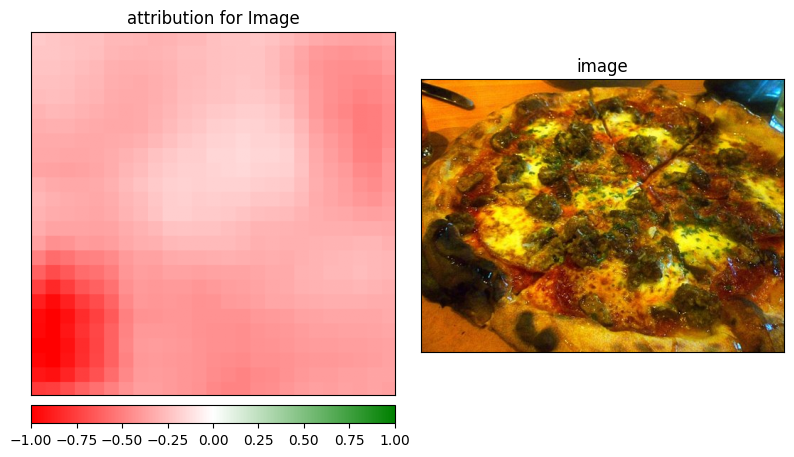

In [81]:
import numpy as np
from captum.attr import visualization as viz

# 계산 속성 Tensor를 이미지 같은 numpy 배열로 변환합니다.
attribution_image = np.transpose(attribution_image.squeeze().cpu().detach().numpy(), (1,2,0))

vis_types = ["heat_map", "original_image"]
vis_signs = ["all", "all"] # "positive", "negative", 또는 모두 표시하는 "all"
# positive 속성은 해당 영역의 존재가 예측 점수를 증가시킨다는 것을 의미합니다.
# negative 속성은 해당 영역의 존재가 예측 점수를 낮추는 오답 영역을 의미합니다.

_ = viz.visualize_image_attr_multiple(attribution_image,
                                      np.array(img),
                                      vis_types,
                                      vis_signs,
                                      ["attribution for Image", "image"],
                                      show_colorbar = True
                                     )